## Tarea Individual Clasificación

In [ ]:
# La tarea se puede entregar en html o ipynb

In [ ]:
## IMPORTACION INICIAL DE LIBRERIAS (no tocar esta celda con estas librerias deberia ser suficiente para resolver la tarea)


# scikit learn
# Arboles de decision
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz

# Crear conjuntos de entrenamiento y test
from sklearn.model_selection import train_test_split

# metricas de clasificacion y visualizaciones
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)

### Leer fichero csv en dataframe  `df`

Para que el siguiente paso funcione será necesario subir el fichero a la ruta actual

In [ ]:
df= pd.read_csv('MatchesPredictResult.csv')

In [ ]:
df.head(20)

,Blocked_Shots_H,Corner_Kicks_H,Fouls_H,Goalkeeper_Saves_H,Offsides_H,Passes_%_H,Passes_accurate_H,Red_Cards_H,Shots_insidebox_H,Shots_outsidebox_H,...,Passes_%_A,Passes_accurate_A,Red_Cards_A,Shots_insidebox_A,Shots_outsidebox_A,Total_Shots_A,Total_passes_A,Yellow_Cards_A,target,Ball_Pos_Diff
0,2.0,5,8,4.0,1.0,0.763920,343,0.0,7,7,...,0.777042,352,0.0,9,9,18,453,2.0,0,-2
1,2.0,7,10,7.0,3.0,0.705382,249,0.0,6,4,...,0.775457,297,0.0,11,6,17,383,2.0,1,-6
2,3.0,3,12,2.0,0.0,0.719807,298,0.0,7,7,...,0.583673,143,0.0,8,5,13,245,2.0,1,24
3,4.0,9,11,2.0,1.0,0.859031,585,0.0,9,8,...,0.550265,104,0.0,4,3,7,189,2.0,0,52
4,4.0,4,7,4.0,3.0,0.853002,412,0.0,6,3,...,0.869875,488,0.0,8,3,11,561,1.0,1,-6
5,1.0,5,13,3.0,4.0,0.795876,386,0.0,6,3,...,0.793319,380,0.0,12,4,16,479,3.0,1,0
6,4.0,7,16,2.0,1.0,0.863309,480,0.0,9,7,...,0.734286,257,0.0,4,3,7,350,2.0,0,22
7,1.0,4,11,1.0,2.0,0.833333,340,0.0,7,5,...,0.849906,453,0.0,7,6,13,533,2.0,0,-14
8,2.0,7,12,2.0,3.0,0.728532,263,0.0,5,3,...,0.807302,398,0.0,9,3,12,493,4.0,1,-16
9,0.0,1,14,5.0,3.0,0.619048,130,0.0,0,3,...,0.902123,765,0.0,9,17,26,848,1.0,0,-62


**Tarea 1 Observamos los tipos de las columnas del dataframe `df` (5 puntos)**

In [ ]:
df.dtypes

,0
Blocked_Shots_H,float64
Corner_Kicks_H,int64
Fouls_H,int64
Goalkeeper_Saves_H,float64
Offsides_H,float64
Passes_%_H,float64
Passes_accurate_H,int64
Red_Cards_H,float64
Shots_insidebox_H,int64
Shots_outsidebox_H,int64


**Tarea 2 Observar el recuento, media, desviación típica de las columnas del dataframe  `df` (5 puntos)**

In [ ]:
df.describe()

,Blocked_Shots_H,Corner_Kicks_H,Fouls_H,Goalkeeper_Saves_H,Offsides_H,Passes_%_H,Passes_accurate_H,Red_Cards_H,Shots_insidebox_H,Shots_outsidebox_H,...,Passes_%_A,Passes_accurate_A,Red_Cards_A,Shots_insidebox_A,Shots_outsidebox_A,Total_Shots_A,Total_passes_A,Yellow_Cards_A,target,Ball_Pos_Diff
count,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,...,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000
mean,3.706379,5.632270,10.320826,2.727017,2.211069,0.779130,370.360225,0.055347,8.686679,5.229831,...,0.770440,354.423077,0.054409,6.981238,4.425891,11.387430,448.103189,1.873358,0.394934,0.864916
std,2.480174,2.969935,3.442932,1.860275,1.649444,0.078744,145.565550,0.236831,4.065814,3.022403,...,0.078093,140.484675,0.231030,3.515442,2.607797,4.936497,138.539744,1.190693,0.489066,26.557026
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.510870,94.000000,0.000000,0.000000,0.000000,...,0.520619,101.000000,0.000000,0.000000,0.000000,1.000000,185.000000,0.000000,0.000000,-64.000000
25%,2.000000,4.000000,8.000000,1.000000,1.000000,0.729249,264.500000,0.000000,6.000000,3.000000,...,0.721693,248.000000,0.000000,4.000000,3.000000,8.000000,346.000000,1.000000,0.000000,-18.000000
50%,3.000000,5.000000,10.000000,2.000000,2.000000,0.788770,348.000000,0.000000,8.000000,5.000000,...,0.780613,332.000000,0.000000,7.000000,4.000000,11.000000,427.500000,2.000000,0.000000,0.000000
75%,5.000000,8.000000,12.000000,4.000000,3.000000,0.837671,460.750000,0.000000,11.000000,7.000000,...,0.829652,444.500000,0.000000,9.000000,6.000000,15.000000,534.000000,2.750000,1.000000,22.000000
max,14.000000,18.000000,24.000000,9.000000,10.000000,0.928947,942.000000,2.000000,24.000000,21.000000,...,0.927254,905.000000,2.000000,21.000000,18.000000,30.000000,976.000000,7.000000,1.000000,64.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1066 entries, 0 to 1065
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Blocked_Shots_H     1066 non-null   float64
 1   Corner_Kicks_H      1066 non-null   int64  
 2   Fouls_H             1066 non-null   int64  
 3   Goalkeeper_Saves_H  1066 non-null   float64
 4   Offsides_H          1066 non-null   float64
 5   Passes_%_H          1066 non-null   float64
 6   Passes_accurate_H   1066 non-null   int64  
 7   Red_Cards_H         1066 non-null   float64
 8   Shots_insidebox_H   1066 non-null   int64  
 9   Shots_outsidebox_H  1066 non-null   int64  
 10  Total_Shots_H       1066 non-null   int64  
 11  Total_passes_H      1066 non-null   int64  
 12  Yellow_Cards_H      1066 non-null   float64
 13  Blocked_Shots_A     1066 non-null   float64
 14  Corner_Kicks_A      1066 non-null   int64  
 15  Fouls_A             1066 non-null   int64  
 16  Goalke

**Tarea 3 Creamos un gráfico con Seaborn de dispersión `sns.scatterplot()` con los datos del dataframe`df` (5 puntos)**


*   Eje X `Shots_insidebox_H` (Remates desde dentro del area equipo Visitante)
*   Eje Y  `Shots_insidebox_A` (Remates desde dentro del area equipo Visitante)
*   colorear (hue) en base al campo `target`
*   tamaño del punto 100 (`s=100`)



<Axes: xlabel='Shots_insidebox_H', ylabel='Shots_insidebox_A'>

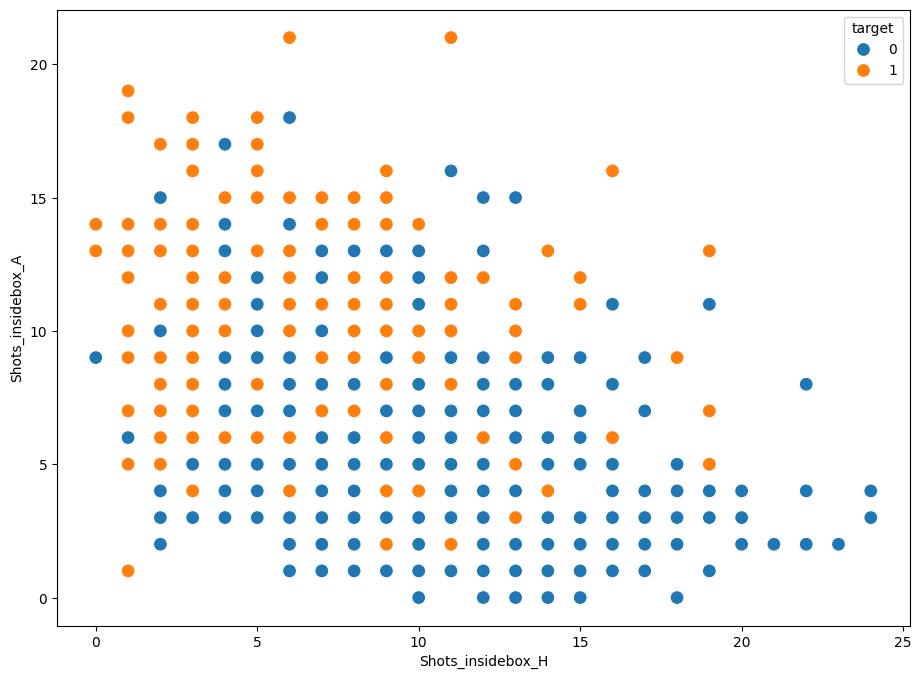

In [ ]:
plt.figure (figsize=(11,8))
sns.scatterplot (data=df, x="Shots_insidebox_H", y= "Shots_insidebox_A",s=100, hue="target")

**Tarea 4  Añadir columna `target_texto` con el valor de texto para la variable objetivo `target` apoyándose en el diccionario `dict_labels` y la función `map` (5 Puntos)**


In [ ]:
dict_labels = {0:"Victoria Loc", 1:'Victoria Vis'}
dict_labels

{0: 'Victoria Loc', 1: 'Victoria Vis'}

In [ ]:
df ["target_texto"]= df ["target"].map(dict_labels)

In [ ]:
df.head (5)

,Blocked_Shots_H,Corner_Kicks_H,Fouls_H,Goalkeeper_Saves_H,Offsides_H,Passes_%_H,Passes_accurate_H,Red_Cards_H,Shots_insidebox_H,Shots_outsidebox_H,...,Passes_accurate_A,Red_Cards_A,Shots_insidebox_A,Shots_outsidebox_A,Total_Shots_A,Total_passes_A,Yellow_Cards_A,target,Ball_Pos_Diff,target_texto
0,2.0,5,8,4.0,1.0,0.763920,343,0.0,7,7,...,352,0.0,9,9,18,453,2.0,0,-2,Victoria Loc
1,2.0,7,10,7.0,3.0,0.705382,249,0.0,6,4,...,297,0.0,11,6,17,383,2.0,1,-6,Victoria Vis
2,3.0,3,12,2.0,0.0,0.719807,298,0.0,7,7,...,143,0.0,8,5,13,245,2.0,1,24,Victoria Vis
3,4.0,9,11,2.0,1.0,0.859031,585,0.0,9,8,...,104,0.0,4,3,7,189,2.0,0,52,Victoria Loc
4,4.0,4,7,4.0,3.0,0.853002,412,0.0,6,3,...,488,0.0,8,3,11,561,1.0,1,-6,Victoria Vis



**Tarea 5 Creación conjuntos `X,y` (5 Puntos)**

**Creamos el la matriz X seleccionando las 27 columnas de la lista ColumnasSelecc**


**Creamos el el vector y**
Seleccionando únicamente la columna **target**

In [ ]:
ColumnasSelecc=['Blocked_Shots_H', 'Corner_Kicks_H', 'Fouls_H', 'Goalkeeper_Saves_H','Offsides_H', 'Passes_%_H', 'Passes_accurate_H', 'Red_Cards_H',
       'Shots_insidebox_H', 'Shots_outsidebox_H', 'Total_Shots_H','Total_passes_H', 'Yellow_Cards_H', 'Blocked_Shots_A', 'Corner_Kicks_A',
       'Fouls_A', 'Goalkeeper_Saves_A', 'Offsides_A', 'Passes_%_A','Passes_accurate_A', 'Red_Cards_A', 'Shots_insidebox_A','Shots_outsidebox_A', 'Total_Shots_A', 'Total_passes_A',
       'Yellow_Cards_A','Ball_Pos_Diff']

In [ ]:
x= df[ColumnasSelecc]
y= df["target"]


**Tarea 6 Crear los 4 conjuntos de `X_train, X_test, y_train, y_test`  (5 Puntos)**

* **80% entrenamiento**
* **20% test**
* utilizar random_state =42


---



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [ ]:
X_train.shape


(852, 27)

In [ ]:
X_test.shape

(214, 27)

In [ ]:
y_train.shape

(852,)

In [ ]:
y_test.shape

(214,)

**Tarea 7 Instanciar Objeto `DecisionTreeClassifier` (10 puntos)**
## Instanciamos el objeto DT
Se pueden utilizar los parámetros que se quiera para probar por ejemplo la máxima profundidad del árbol `max_depth`

In [ ]:
DT = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)


**Tarea 8 entrenar el modelo sobre los conjuntos de entrenamiento (10 puntos)**

**Entrenar el modelo DT**

In [ ]:
DT.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

**Tarea 9 realizar la prediccion con `predict` sobre el conjunto `X_test` y guardarla dentro de un vector denominado `y_pred` (10 puntos)**

**Realizar la predicción**

In [ ]:
y_pred= DT.predict (X_test)

In [ ]:
y_pred.shape

(214,)

**Tarea 10 observar la precisión global del modelo utilizando la función `accuracy_score` sobre los conjuntos `y_test` e `y_pred` (5 puntos)**

In [ ]:
accuracy_score (y_test, y_pred)

0.6915887850467289

**Tarea 11 mostrar gráficamente la matriz de confusión para los conjuntos `y_test` e `y_pred` (10 puntos) crear una versión normalizada por filas y otra no normalizada con valores absolutos**
* En este apartado será necesario utilizar `ConfusionMatrixDisplay.from_estimator()`

* Se incluye el diccionario `dict_labels_mat_conf` para poder utilizarlo dentro de `display_labels=dict_labels_mat_conf.keys()`

In [ ]:
dict_labels_mat_conf = {"Victoria Loc":0, 'Victoria Vis':1}
dict_labels_mat_conf

{'Victoria Loc': 0, 'Victoria Vis': 1}

In [ ]:
MatConf= confusion_matrix (y_test,y_pred)
MatConf

array([[94, 35],
       [31, 54]])

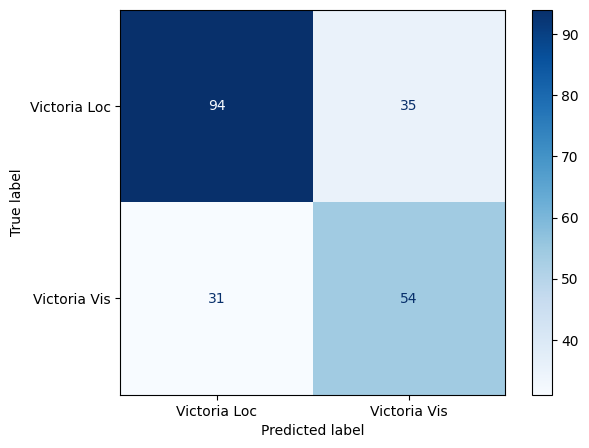

In [ ]:
fig,ax=plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_estimator(DT, X_test, y_test,
                                       cmap="Blues",
                                       display_labels=dict_labels_mat_conf.keys(),
                                       ax=ax)
plt.show()

Version normalizada

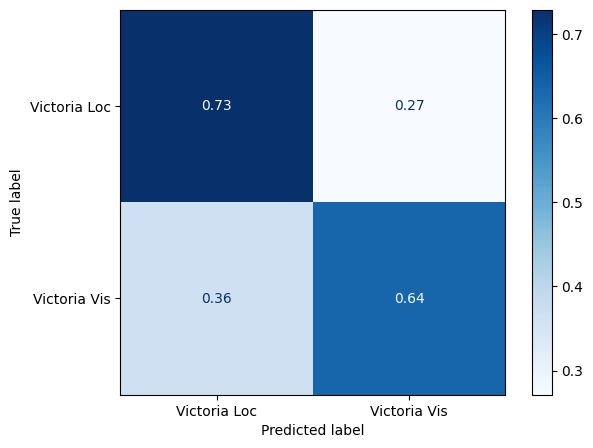

In [ ]:
fig,ax=plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_estimator(DT, X_test, y_test,
                                      cmap="Blues",
                                       display_labels=dict_labels_mat_conf.keys(),
                                      normalize= "true",
                                       ax=ax)
plt.show()

**Tarea 12 utilizando `classification_report` observar el detalle de las métricas de clasificación (10 puntos)**


In [ ]:
print(classification_report (y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.73      0.74       129
           1       0.61      0.64      0.62        85

    accuracy                           0.69       214
   macro avg       0.68      0.68      0.68       214
weighted avg       0.69      0.69      0.69       214



**Tarea 13 Visualización del árbol creado con el método `plot_tree` (15 puntos)**

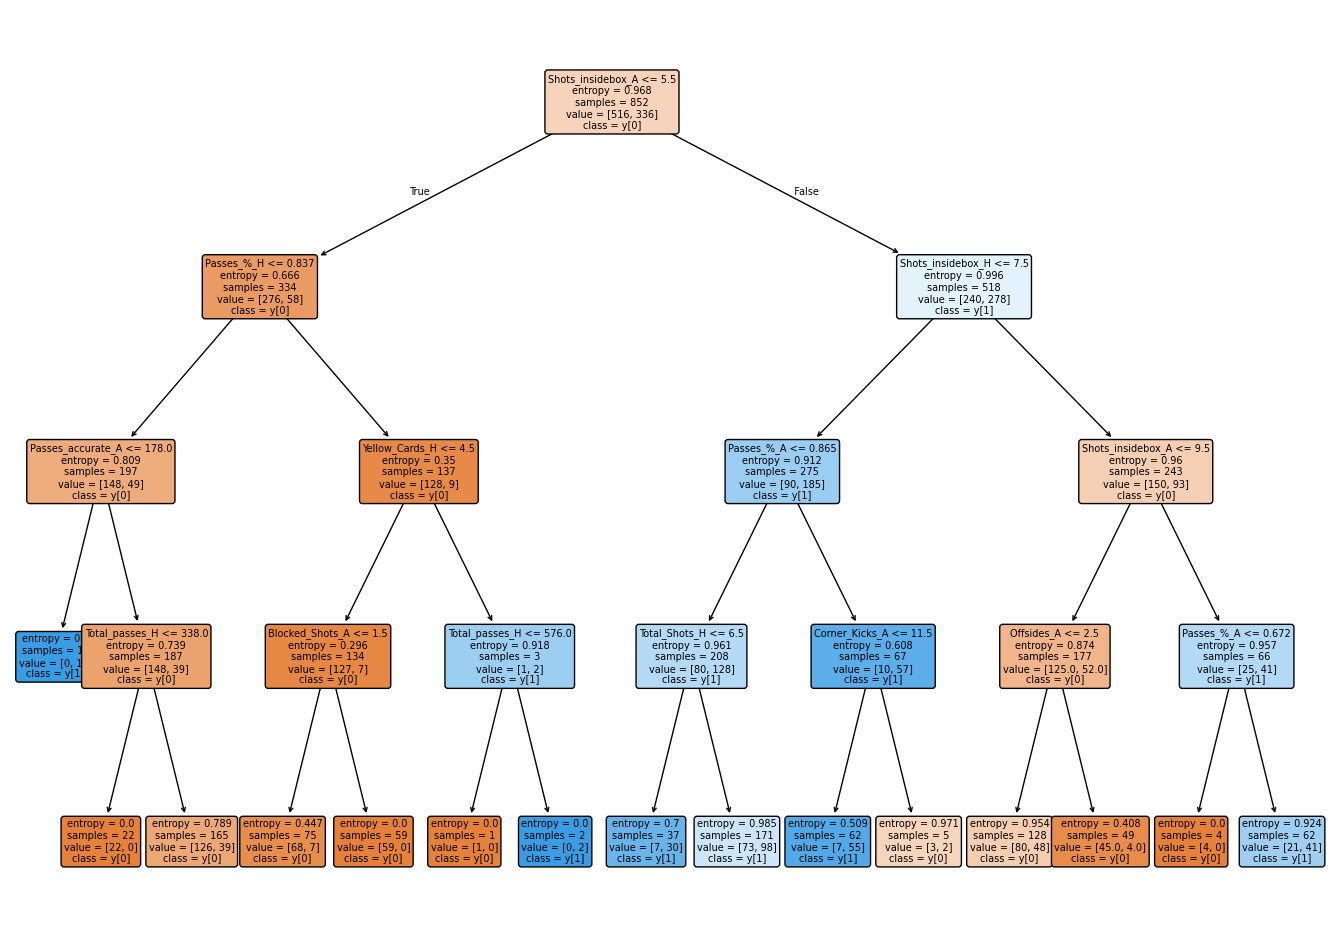

In [ ]:
plt.figure(figsize=(17,12))
plot_tree(DT,
          feature_names=ColumnasSelecc,
          class_names=True,
          filled=True,
          rounded=True,
          fontsize=7)
plt.show()